In [1]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt

# anchor 数量

## anchor 总数

Running with num_anchors = 0...
Error running ['../anchor_mapping', '--num_anchors', '0', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--maxDist', '3']: 

stack trace:
  0          [0x406f22]  ../anchor_mapping()
  1    [0x7f11f9a30090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2          [0x42ad6b]  ../anchor_mapping()
  3    [0x7f11f9a11083]  __libc_start_main + 0xf3
  4          [0x40520e]  ../anchor_mapping()


Running with num_anchors = 5...
Running with num_anchors = 10...
Running with num_anchors = 15...


Running with num_anchors = 20...
Running with num_anchors = 25...
Running with num_anchors = 30...
Running with num_anchors = 35...
Running with num_anchors = 40...
Running with num_anchors = 45...
Running with num_anchors = 50...
Running with num_anchors = 55...
Running with num_anchors = 60...
Running with num_anchors = 65...
Running with num_anchors = 70...
Running with num_anchors = 75...
Running with num_anchors = 80...
Running with num_anchors = 85...
Running with num_anchors = 90...
Running with num_anchors = 95...
    avg_tp   avg_fp  avg_fn  avg_recall  avg_precision  num_anchors
0     3.00  5542.48     0.0         1.0       0.010637            5
1     3.00  3341.04     0.0         1.0       0.011292           10
2     3.00  1937.56     0.0         1.0       0.012250           15
3     3.00  1243.18     0.0         1.0       0.005854           20
4     3.00   774.15     0.0         1.0       0.009175           25
5     3.00   528.87     0.0         1.0       0.016885          

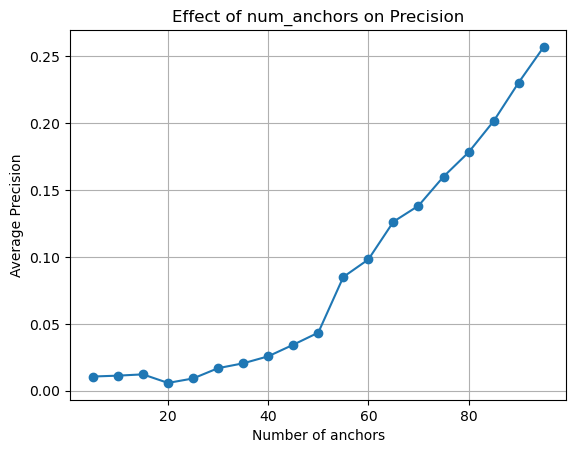

In [2]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(0, 100, 5)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o")
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

Running with num_anchors = 0...


Error running ['../anchor_mapping', '--num_anchors', '0', '--truncate_ref_len', '10000', '--anchor_len', '20', '--num_queries', '100', '--maxDist', '3']: 

stack trace:
  0          [0x406f22]  ../anchor_mapping()
  1    [0x7f76163a5090]  /lib/x86_64-linux-gnu/libc.so.6(+0x43090)
  2          [0x42ad6b]  ../anchor_mapping()
  3    [0x7f7616386083]  __libc_start_main + 0xf3
  4          [0x40520e]  ../anchor_mapping()


Running with num_anchors = 100...
Running with num_anchors = 200...
Running with num_anchors = 300...
Running with num_anchors = 400...
Running with num_anchors = 500...
Running with num_anchors = 600...
Running with num_anchors = 700...
Running with num_anchors = 800...
Running with num_anchors = 900...
   avg_tp  avg_fp  avg_fn  avg_recall  avg_precision  num_anchors
0    3.00   13.51     0.0         1.0       0.291423          100
1    3.00    1.00     0.0         1.0       0.798143          200
2    3.00    0.33     0.0         1.0       0.920500          300
3    3.

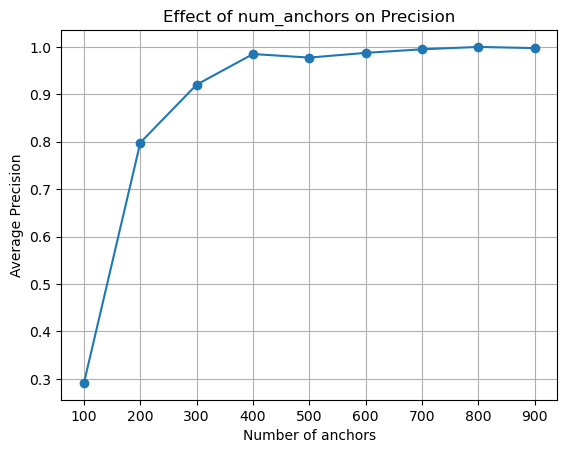

In [3]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
anchor_values = range(0, 1000, 100)

results = []

for n in anchor_values:
    print(f"Running with num_anchors = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(n),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", "3",
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for num_anchors={n}")
            metrics[key] = None

    metrics["num_anchors"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_anchor_full.csv", index=False)

# 画图
plt.plot(df["num_anchors"], df["avg_precision"], marker="o")
plt.xlabel("Number of anchors")
plt.ylabel("Average Precision")
plt.title("Effect of num_anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_anchor_full.png")
plt.show()

# 允许的 error 范围

Running with maxDist = 1...


Running with maxDist = 2...
Running with maxDist = 3...
Running with maxDist = 4...
Running with maxDist = 5...
Running with maxDist = 6...
Running with maxDist = 7...
Running with maxDist = 8...
Running with maxDist = 9...
Running with maxDist = 10...
Running with maxDist = 11...
Running with maxDist = 12...
Running with maxDist = 13...
Running with maxDist = 14...
Running with maxDist = 15...
Running with maxDist = 16...
Running with maxDist = 17...
Running with maxDist = 18...
Running with maxDist = 19...
Running with maxDist = 20...
     avg_tp   avg_fp  avg_fn  avg_recall  avg_precision  maxDist
0      1.00     0.00     0.0         1.0       1.000000        1
1      3.01     0.00     0.0         1.0       1.000000        2
2      3.03     0.01     0.0         1.0       0.997500        3
3      5.07     0.96     0.0         1.0       0.879982        4
4      5.33    72.94     0.0         1.0       0.288299        5
5     10.16   786.55     0.0         1.0       0.170830        6
6 

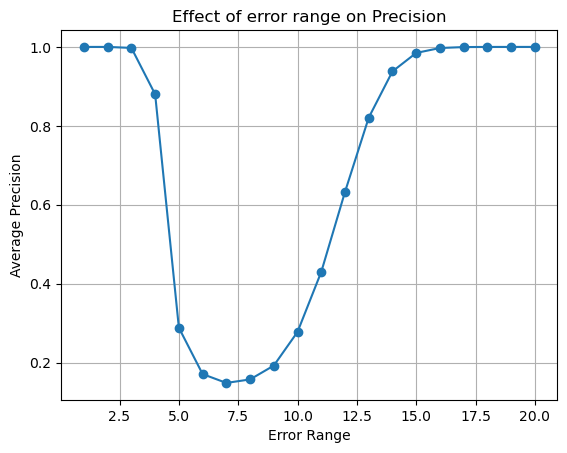

In [4]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围（你可以改成别的参数 sweep）
error_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

results = []

for n in error_values:
    print(f"Running with maxDist = {n}...")
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--maxDist", str(n),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":       r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":       r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":       r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":   r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision":r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for maxDist={n}")
            metrics[key] = None

    metrics["maxDist"] = n
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 保存结果
df.to_csv("./csv/sweep_results_max_dist.csv", index=False)

# 画图
plt.plot(df["maxDist"], df["avg_precision"], marker="o")
plt.xlabel("Error Range")
plt.ylabel("Average Precision")
plt.title("Effect of error range on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_max_dist.png")
plt.show()

# anchor距离（滑窗，从近到远稳定 20 个）

Running with start_idx=0, end_idx=10 ...


Running with start_idx=10, end_idx=20 ...
Running with start_idx=20, end_idx=30 ...
Running with start_idx=30, end_idx=40 ...
Running with start_idx=40, end_idx=50 ...
Running with start_idx=50, end_idx=60 ...
Running with start_idx=60, end_idx=70 ...
Running with start_idx=70, end_idx=80 ...
Running with start_idx=80, end_idx=90 ...
Running with start_idx=90, end_idx=100 ...
   avg_tp   avg_fp  avg_fn  avg_recall  avg_precision  start_idx  end_idx
0    3.03     8.41     0.0         1.0       0.611018          0       10
1    3.03   174.83     0.0         1.0       0.045836         10       20
2    3.03   328.08     0.0         1.0       0.014671         20       30
3    3.03   671.57     0.0         1.0       0.009309         30       40
4    3.03  1126.88     0.0         1.0       0.006137         40       50
5    3.03  1429.34     0.0         1.0       0.003517         50       60
6    3.03  1654.02     0.0         1.0       0.002607         60       70
7    3.03  1915.19     0.0   

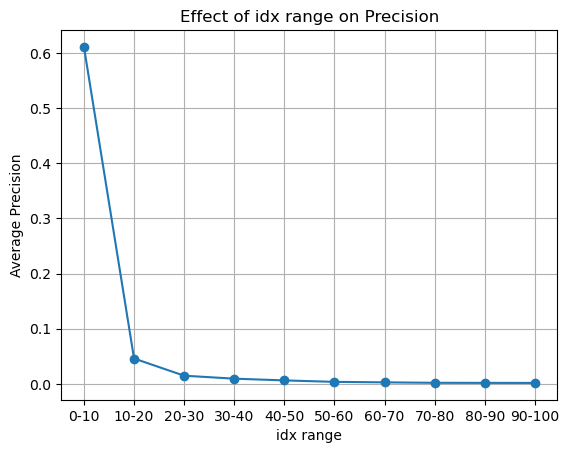

In [5]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import os

# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

# sweep 范围：start_idx, end_idx
idx_ranges = [(i, i+10) for i in range(0, 100, 10)]


results = []

for start_idx, end_idx in idx_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    
    # 调用你的程序
    cmd = [
        EXECUTABLE,
        "--num_anchors", "1000",
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    # 提取平均指标
    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

# 确保输出目录存在
os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

# 保存结果
df.to_csv("./csv/sweep_results_idx.csv", index=False)

# 画图
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("idx range")
plt.ylabel("Average Precision")
plt.title("Effect of idx range on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_idx.png")
plt.show()

# anchor 从近到远的 elbow（选前 n 个）

Running with start_idx=0.000000, end_idx=1.000000 ...


Running with start_idx=0.000000, end_idx=2.000000 ...
Running with start_idx=0.000000, end_idx=3.000000 ...
Running with start_idx=0.000000, end_idx=4.000000 ...
Running with start_idx=0.000000, end_idx=5.000000 ...
Running with start_idx=0.000000, end_idx=6.000000 ...
Running with start_idx=0.000000, end_idx=7.000000 ...
Running with start_idx=0.000000, end_idx=8.000000 ...
Running with start_idx=0.000000, end_idx=9.000000 ...
Running with start_idx=0.000000, end_idx=10.000000 ...
Running with start_idx=0.000000, end_idx=11.000000 ...
Running with start_idx=0.000000, end_idx=12.000000 ...
Running with start_idx=0.000000, end_idx=13.000000 ...
Running with start_idx=0.000000, end_idx=14.000000 ...
Running with start_idx=0.000000, end_idx=15.000000 ...
Running with start_idx=0.000000, end_idx=16.000000 ...
Running with start_idx=0.000000, end_idx=17.000000 ...
Running with start_idx=0.000000, end_idx=18.000000 ...
Running with start_idx=0.000000, end_idx=19.000000 ...
Running with start

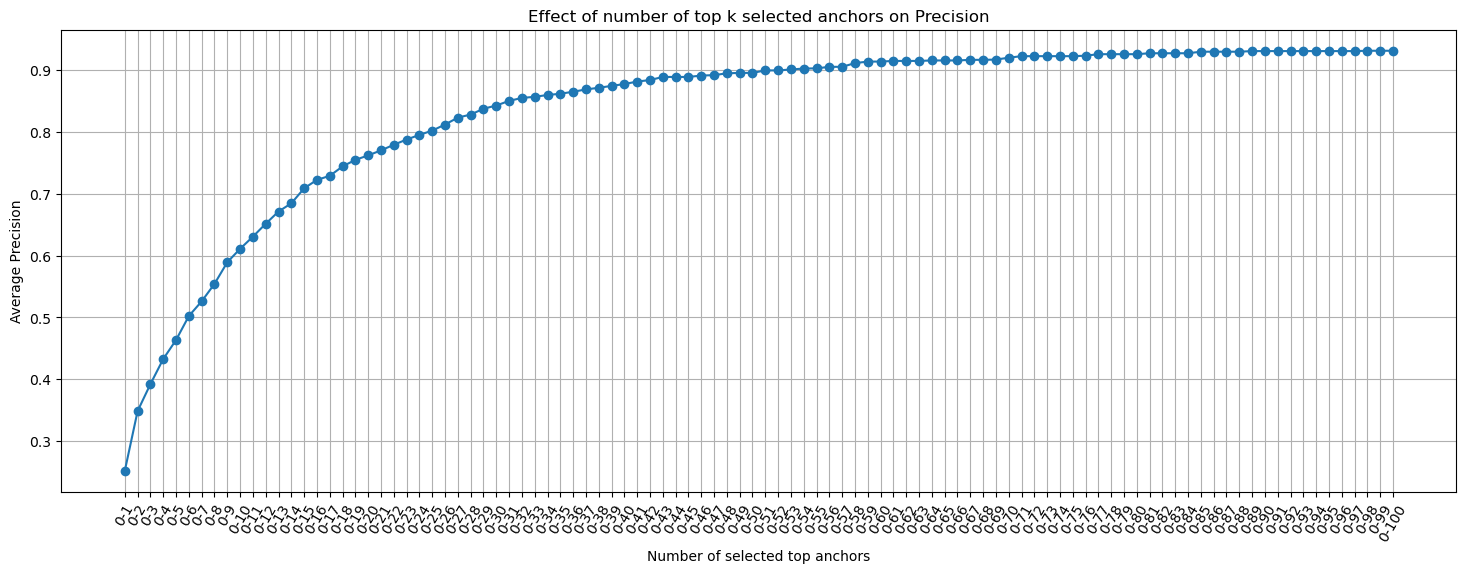

In [6]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={f"{start_idx:.6f}"}, end_idx={f"{end_idx:.6f}"} ...")
    
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(f"{start_idx:.6f}"),
        "--end_idx", str(f"{end_idx:.6f}"),
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
        "end_idx": r"Start and end indexes: 0, \s*([0-9.eE+-]+)"
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.figure(figsize=(18, 6))
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors", )
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors.png")
plt.show()

In [7]:
df_normal = df.copy()

Running with start_idx=0.0, end_idx=1 ...
Running with start_idx=0.0, end_idx=2 ...
Running with start_idx=0.0, end_idx=3 ...


Running with start_idx=0.0, end_idx=4 ...
Running with start_idx=0.0, end_idx=5 ...
Running with start_idx=0.0, end_idx=6 ...
Running with start_idx=0.0, end_idx=7 ...
Running with start_idx=0.0, end_idx=8 ...
Running with start_idx=0.0, end_idx=9 ...
Running with start_idx=0.0, end_idx=10 ...
Running with start_idx=0.0, end_idx=11 ...
Running with start_idx=0.0, end_idx=12 ...
Running with start_idx=0.0, end_idx=13 ...
Running with start_idx=0.0, end_idx=14 ...
Running with start_idx=0.0, end_idx=15 ...
Running with start_idx=0.0, end_idx=16 ...
Running with start_idx=0.0, end_idx=17 ...
Running with start_idx=0.0, end_idx=18 ...
Running with start_idx=0.0, end_idx=19 ...
Running with start_idx=0.0, end_idx=20 ...
Running with start_idx=0.0, end_idx=21 ...
Running with start_idx=0.0, end_idx=22 ...
Running with start_idx=0.0, end_idx=23 ...
Running with start_idx=0.0, end_idx=24 ...
Running with start_idx=0.0, end_idx=25 ...
Running with start_idx=0.0, end_idx=26 ...
Running with star

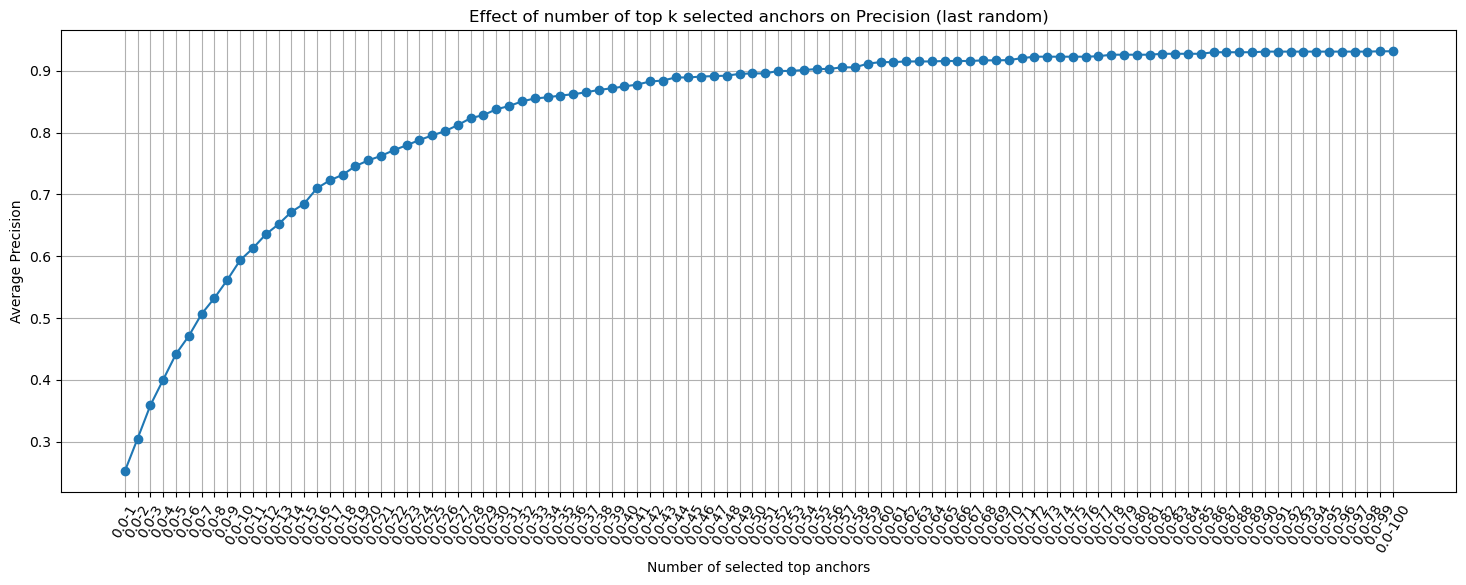

In [8]:
# 可执行程序路径
EXECUTABLE = "../anchor_mapping"

num_anchors = 1000  # 用于计算选中 anchor 数量

# sweep 范围：start_idx, end_idx
frac_ranges = [(0.0, i) for i in range(1, 101)]

results = []

for start_idx, end_idx in frac_ranges:
    print(f"Running with start_idx={start_idx}, end_idx={end_idx} ...")
    
    cmd = [
        EXECUTABLE,
        "--num_anchors", str(num_anchors),
        "--truncate_ref_len", "10000",
        "--anchor_len", "20",
        "--num_queries", "100",
        "--use_all", "false",
        "--start_idx", str(start_idx),
        "--end_idx", str(end_idx),
        "--last_random", "true"
    ]
    proc = subprocess.run(cmd, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"Error running {cmd}: {proc.stderr}")
        continue

    output = proc.stdout

    metrics = {}
    patterns = {
        "avg_tp":        r"Average TP:\s*([0-9.eE+-]+)",
        "avg_fp":        r"Average FP:\s*([0-9.eE+-]+)",
        "avg_fn":        r"Average FN:\s*([0-9.eE+-]+)",
        "avg_recall":    r"Average Recall:\s*([0-9.eE+-]+)",
        "avg_precision": r"Average Precision:\s*([0-9.eE+-]+)",
    }

    for key, pat in patterns.items():
        m = re.search(pat, output)
        if m:
            metrics[key] = float(m.group(1))
        else:
            print(f"⚠️ {key} not found in output for idx=({start_idx},{end_idx})")
            metrics[key] = None

    metrics["start_idx"] = start_idx
    metrics["end_idx"] = end_idx
    metrics["selected_anchors"] = end_idx  # 新增一列
    results.append(metrics)

# 转 DataFrame
df = pd.DataFrame(results)
print(df)

os.makedirs("./csv", exist_ok=True)
os.makedirs("./fig", exist_ok=True)

df.to_csv("./csv/sweep_results_by_num_top_anchors_last_random.csv", index=False)

# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

In [9]:
df_random = df.copy()

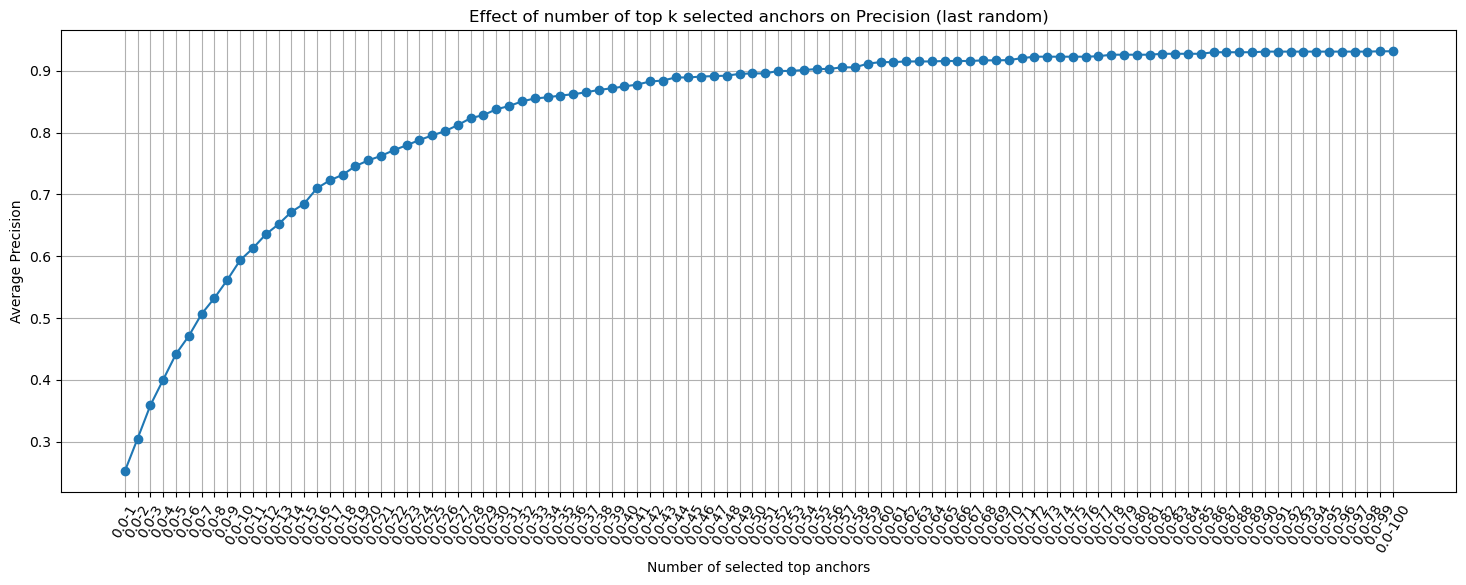

In [10]:
df = df_random
# 画图，用 selected_anchors 作为 x 轴
plt.figure(figsize=(18, 6))
x_labels = [f"{s}-{e}" for s,e in zip(df["start_idx"], df["end_idx"])]
plt.plot(x_labels, df["avg_precision"], marker="o")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.xticks(rotation=60)
plt.title("Effect of number of top k selected anchors on Precision (last random)")
plt.grid(True)
plt.savefig("./fig/sweep_precision_by_num_top_anchors_last_random.png")
plt.show()

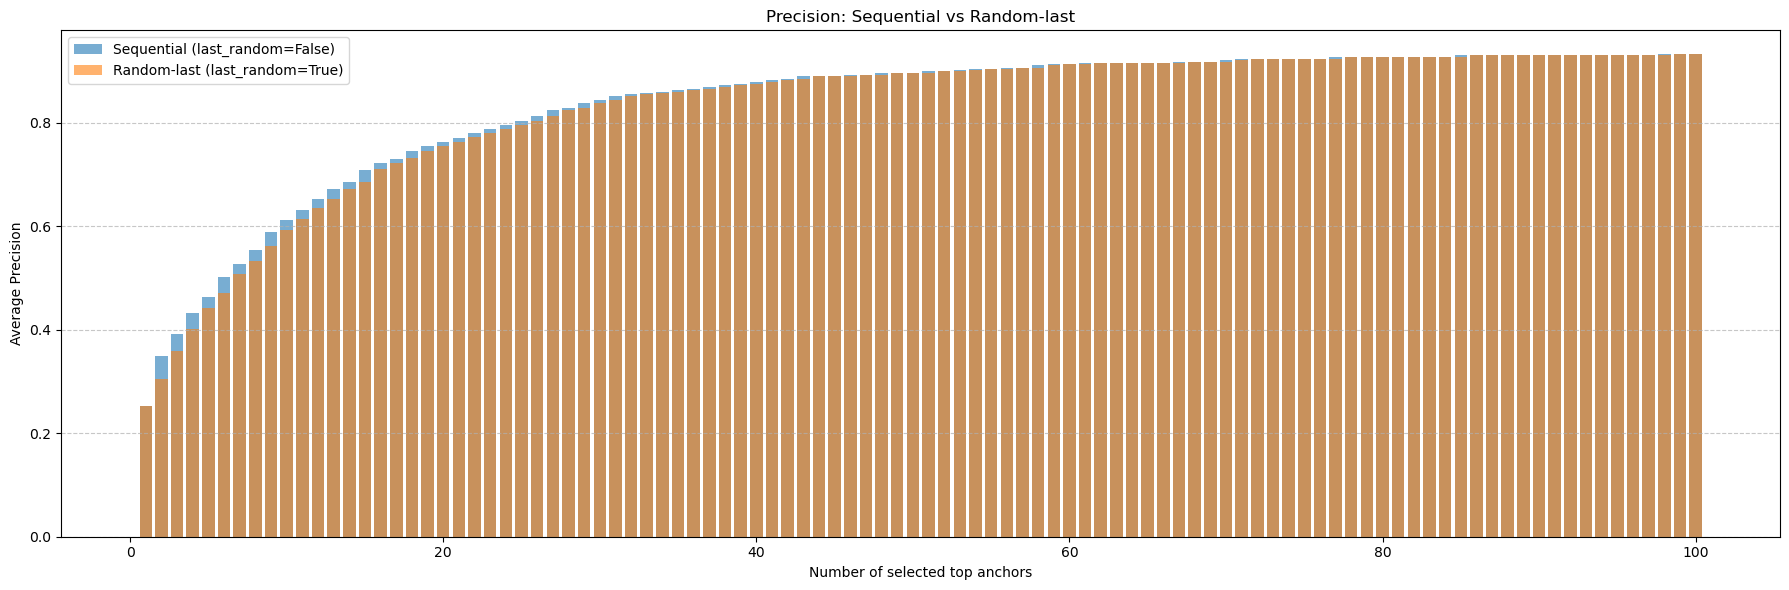

In [11]:
x = df_normal["selected_anchors"].values
y_normal = df_normal["avg_precision"].values
y_random = df_random["avg_precision"].values

plt.figure(figsize=(18,6))
plt.bar(x, y_normal, alpha=0.6, label="Sequential (last_random=False)")
plt.bar(x, y_random, alpha=0.6, label="Random-last (last_random=True)")

plt.xlabel("Number of selected top anchors")
plt.ylabel("Average Precision")
plt.title("Precision: Sequential vs Random-last")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_overlap.png")
plt.show()

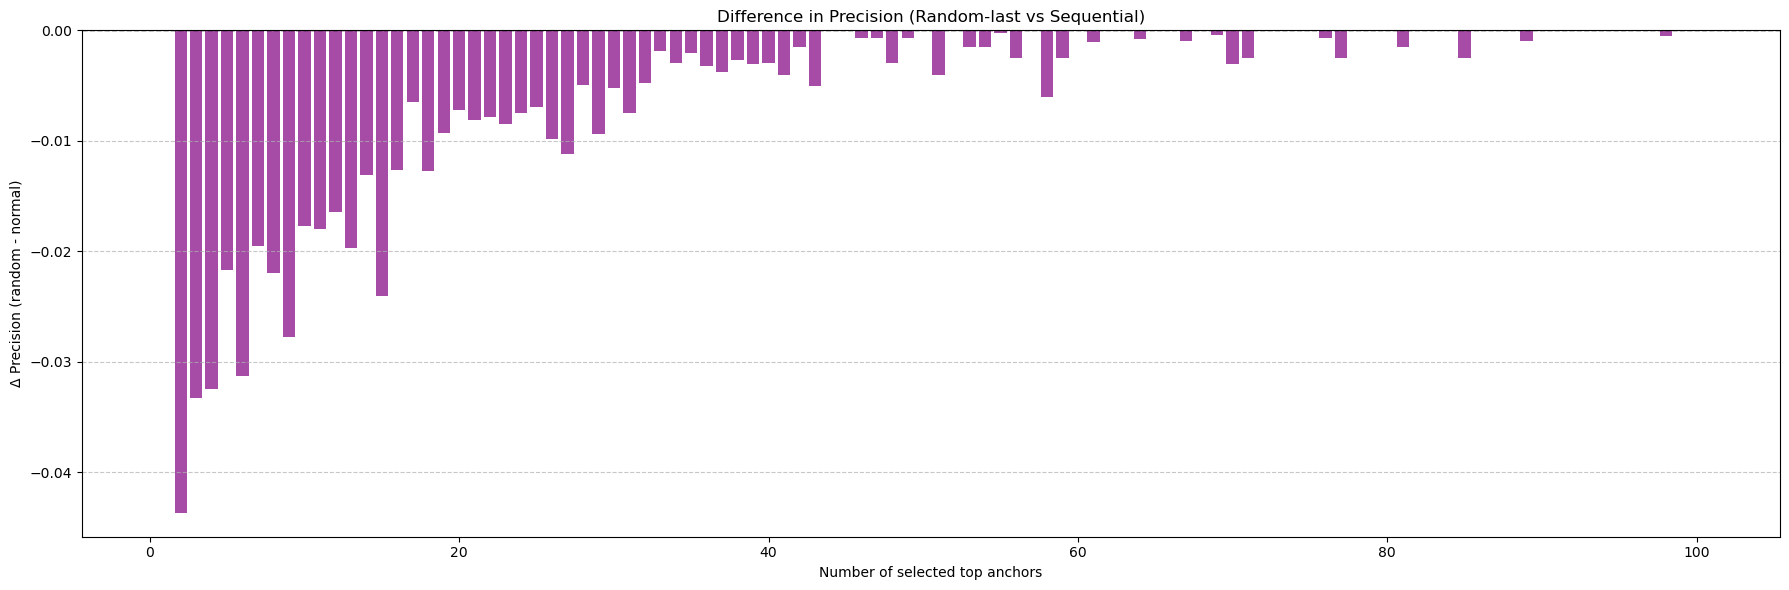

In [12]:
diff = y_random - y_normal

plt.figure(figsize=(18,6))
plt.bar(x, diff, color="purple", alpha=0.7)

plt.axhline(0, color="black", linewidth=1, linestyle="--")
plt.xlabel("Number of selected top anchors")
plt.ylabel("Δ Precision (random - normal)")
plt.title("Difference in Precision (Random-last vs Sequential)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("./fig/precision_difference.png")
plt.show()